**Description**: sanity check that training isn't bottlenecked by dataloading.

Result from training: it's not bottlenecked. GPU util is 90-100%. All dataloading takes a few min on my machine.
Tokenizer is fast.

TODO: run on GPU to include device transfer time.

**Expected time**: 6.5 min.

In [1]:
import time

import numpy as np
import seaborn as sns
import torch
from tqdm.auto import tqdm

import grouping_trainer as gt

import train

In [2]:
sns.set_theme(style="darkgrid")

In [3]:
def record_times(times: list[float]):
    def decorator(func):
        def wrapper(*args, **kwargs):
            start_time = time.monotonic()
            result = func(*args, **kwargs)
            end_time = time.monotonic()
            times.append(end_time - start_time)
            return result

        return wrapper

    return decorator

In [4]:
times_dedupe = []
times_tokenize = []

In [5]:
@record_times(times_dedupe)
def dedupe(queries: list[str], candidates: list[str]) -> tuple[list[str], torch.Tensor]:
    texts_unique, inverse_indices = np.unique(queries + candidates, return_inverse=True)
    inverse_indices = torch.as_tensor(inverse_indices)
    return texts_unique.tolist(), inverse_indices

In [ ]:
@record_times(times_tokenize)
def tokenize(model: gt.utils.SentenceTransformer, texts_unique: list[str]) -> dict[str, torch.Tensor]:
    encodings = model.tokenize(texts_unique, return_tensors="pt", padding=True)
    encodings = {k: v.to(model.device) for k, v in encodings.items()}
    return encodings

In [7]:
def preprocess(
    model: gt.utils.SentenceTransformer, queries: list[str], candidates: list[str]
) -> dict[str, torch.Tensor]:
    texts_unique, _ = dedupe(queries, candidates)
    encodings = tokenize(model, texts_unique)
    return encodings

In [8]:
trainer = gt.train.run(train.model, train.training_config_full, just_make_trainer=True)

Validation dataset: 8,000 rows


Creating project datasets:   0%|          | 0/151 [00:00<?, ?it/s]

Training dataset: 133 projects, 835,765 rows


In [9]:
print(train.training_config_full)

run_shortname='gte' per_device_train_batch_size=256 per_device_token_budget=32768 training_csvs=('final_csvs/train.csv', 'final_csvs/synthetic-semi-easy-negatives.csv') sample_size_train=None gradient_checkpointing=False log_of_scale_init=1.6094379124341003 learning_rate=0.0001 learning_rate_mapping={'^log_scale$': 0.0002, '^bias$': 0.0002} weight_decay=0.01 warmup_ratio=0.1 matryoshka_dims=(768, 512, 256, 128, 64) matryoshka_weights=(2.0, 1.0, 1.0, 0.5, 0.25) n_dims_per_step=2 per_device_eval_batch_size=1 eval_steps=300 sample_size_val=8000 wandb_project='grouping-trainer'


In [10]:
train_dataloader = trainer.get_train_dataloader()
num_sub_batches_per_batch = []
for batch in tqdm(train_dataloader, total=len(train_dataloader)):
    for sub_batch_idx, sub_batch in enumerate(
        gt.train.batch_pairs_by_token_budget(batch, token_budget=train.training_config_full.per_device_token_budget)
    ):
        encodings = preprocess(
            train.model, sub_batch["query_stacktrace_string"], sub_batch["candidate_stacktrace_string"]
        )
    num_sub_batches_per_batch.append(sub_batch_idx + 1)

  0%|          | 0/3334 [00:00<?, ?it/s]

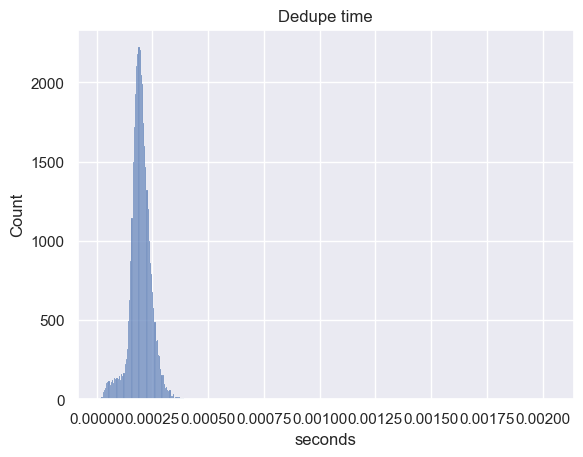

In [11]:
_ = sns.histplot(times_dedupe).set(title="Dedupe time", xlabel="seconds")

In [12]:
sum(times_dedupe)

7.484422283421736

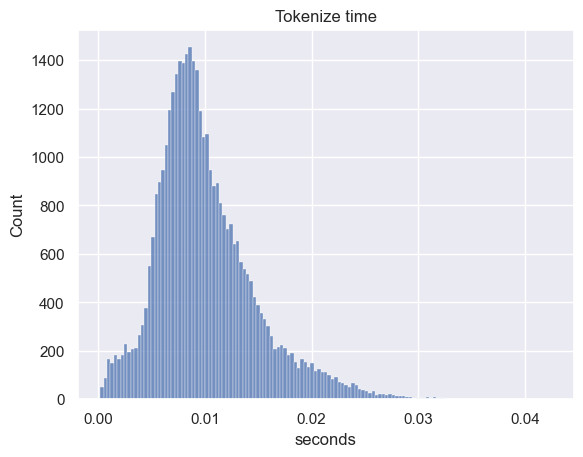

In [13]:
_ = sns.histplot(times_tokenize).set(title="Tokenize time", xlabel="seconds")


In [14]:
sum(times_tokenize)

385.16260897074244

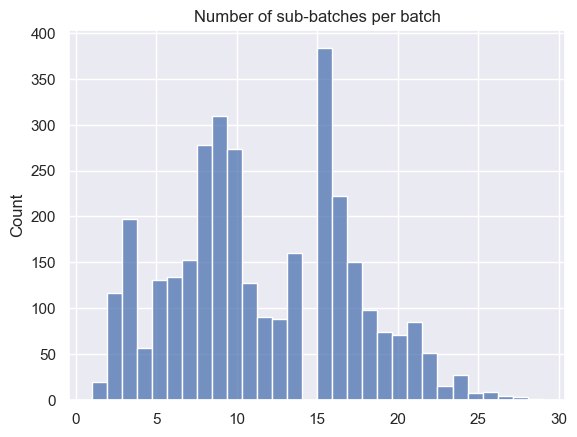

In [15]:
_ = sns.histplot(num_sub_batches_per_batch).set(title="Number of sub-batches per batch")